# Network Performance Anomaly Detection
## Egypt Regions Network Analysis

---

**Objective:** Detect cities, carriers, or days showing abnormal network performance using three anomaly detection methods.

**Methods:**
1. Isolation Forest
2. One-Class SVM (OC-SVM)
3. Autoencoder (PyTorch)

**Output:** This notebook generates files for the Streamlit dashboard to visualize.

## 1. Setup and Data Loading

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Anomaly Detection Models
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

# PyTorch for Autoencoder
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

# Create outputs directory
os.makedirs('outputs', exist_ok=True)

print("Libraries loaded successfully!")

Using device: cpu
PyTorch version: 2.11.0+cpu
Libraries loaded successfully!


In [2]:
# Load the dataset
df = pd.read_csv('Performance.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Dataset Shape: (93364, 14)
Columns: ['aggregate_date', 'place_name', 'region', 'place_type', 'carrier_name', 'aggregation_period', 'technology_type', 'sample_count', 'mean_download_kbps', 'mean_upload_kbps', 'mean_latency_ms', 'median_download_kbps', 'median_upload_kbps', 'median_latency_ms']


,aggregate_date,place_name,region,place_type,carrier_name,aggregation_period,technology_type,sample_count,mean_download_kbps,mean_upload_kbps,mean_latency_ms,median_download_kbps,median_upload_kbps,median_latency_ms
0,2026-03-01,City_69EFF64A,Cairo,locality,Operator A,Day,LTE,1,213558,32467,37,213558,32467,37
1,2026-03-01,City_69EFF64A,Cairo,locality,Operator A,Day,Multi-RAT,1,213558,32467,37,213558,32467,37
2,2026-03-01,City_69EFF64A,Cairo,locality,Operator B,Day,5G,1,402681,80584,25,402681,80584,25
3,2026-03-01,City_69EFF64A,Cairo,locality,Operator B,Day,Multi-RAT,5,88183,22905,46,13733,10406,51
4,2026-03-01,City_69EFF64A,Cairo,locality,Operator B,Day,LTE,4,9559,8485,51,10967,8309,53


In [3]:
# Statistical summary
print("Dataset Statistics:")
df.describe()

Dataset Statistics:


,sample_count,mean_download_kbps,mean_upload_kbps,mean_latency_ms,median_download_kbps,median_upload_kbps,median_latency_ms
count,93364.000000,9.336400e+04,93364.000000,93364.000000,9.336400e+04,93364.000000,93364.000000
mean,37.772964,1.040574e+05,17845.626708,41.204436,9.460949e+04,16153.527527,39.462673
std,474.379735,1.187946e+05,14981.087044,26.174070,1.163168e+05,14914.169222,25.007443
min,1.000000,6.000000e+00,1.000000,1.000000,6.000000e+00,1.000000,1.000000
25%,1.000000,2.406300e+04,7091.750000,30.000000,1.946900e+04,5975.000000,29.000000
50%,2.000000,6.209300e+04,14411.000000,37.000000,5.280300e+04,11969.500000,36.000000
75%,5.000000,1.408845e+05,24390.000000,46.000000,1.222460e+05,21773.000000,44.000000
max,32028.000000,1.135477e+06,157354.000000,687.000000,1.135477e+06,157354.000000,687.000000


In [4]:
# Check unique values in categorical columns
print("Unique Regions:", df['region'].nunique())
print("Regions:", df['region'].unique().tolist())
print("\nUnique Carriers:", df['carrier_name'].nunique())
print("Carriers:", df['carrier_name'].unique().tolist())
print("\nUnique Technologies:", df['technology_type'].nunique())
print("Technologies:", df['technology_type'].unique().tolist())
print("\nPlace Types:", df['place_type'].unique().tolist())
print("\nAggregation Periods:", df['aggregation_period'].unique().tolist())

Unique Regions: 14
Regions: ['Cairo', 'Giza', 'Alexandria', 'Dakahlia', 'Sharqia', 'Gharbia', 'Monufia', 'Port Said', 'Ismailia', 'Fayoum', 'Minya', 'Assiut', 'Sohag', 'Egypt']

Unique Carriers: 3
Carriers: ['Operator A', 'Operator B', 'Operator C']

Unique Technologies: 3
Technologies: ['LTE', 'Multi-RAT', '5G']

Place Types: ['locality', 'country']

Aggregation Periods: ['Day', 'Week']


## 2. Data Filtering and Preprocessing

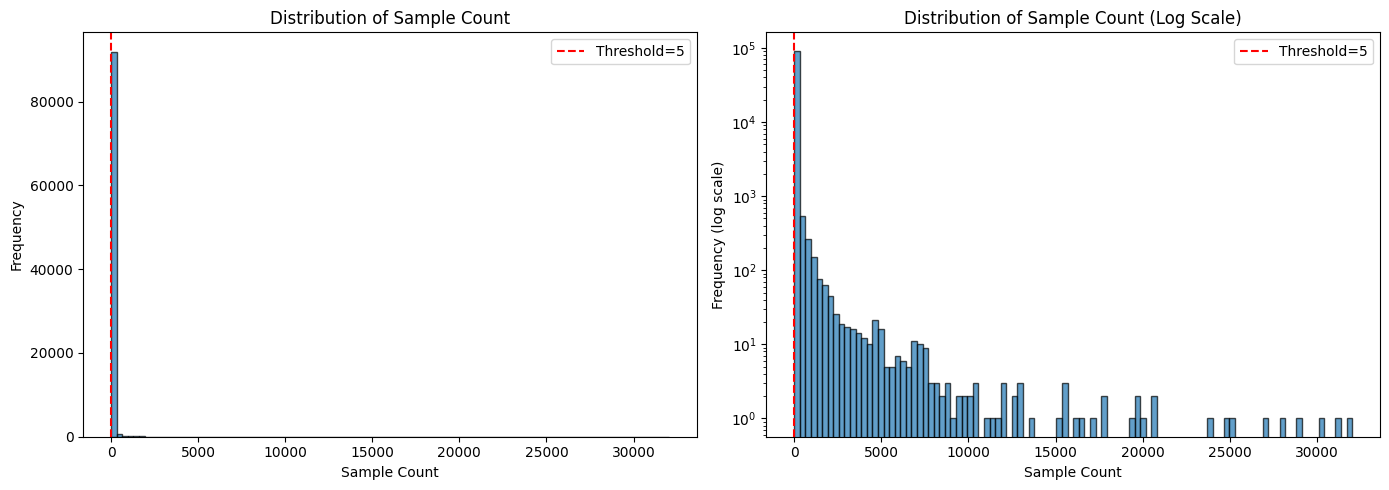


Sample Count Statistics:
count    93364.000000
mean        37.772964
std        474.379735
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      32028.000000
Name: sample_count, dtype: float64


In [5]:
# Analyze sample_count distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['sample_count'], bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Sample Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Sample Count')
axes[0].axvline(x=5, color='red', linestyle='--', label='Threshold=5')
axes[0].legend()

axes[1].hist(df['sample_count'], bins=100, edgecolor='black', alpha=0.7, log=True)
axes[1].set_xlabel('Sample Count')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].set_title('Distribution of Sample Count (Log Scale)')
axes[1].axvline(x=5, color='red', linestyle='--', label='Threshold=5')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/sample_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Sample count statistics
print("\nSample Count Statistics:")
print(df['sample_count'].describe())

In [6]:
# Apply filters
# 1. Sample count threshold (minimum 5 samples for statistical reliability)
df_filtered = df[df['sample_count'] >= 5].copy()
print(f"After sample_count >= 5: {len(df_filtered):,} rows")

# 2. Filter to locality (city-level) data
df_filtered = df_filtered[df_filtered['place_type'] == 'locality'].copy()
print(f"After locality filter: {len(df_filtered):,} rows")

# 3. Focus on daily data
df_filtered = df_filtered[df_filtered['aggregation_period'] == 'Day'].copy()
print(f"After daily filter: {len(df_filtered):,} rows")

# Convert date
df_filtered['aggregate_date'] = pd.to_datetime(df_filtered['aggregate_date'])

print(f"\nDate Range: {df_filtered['aggregate_date'].min()} to {df_filtered['aggregate_date'].max()}")
print(f"Number of unique dates: {df_filtered['aggregate_date'].nunique()}")

After sample_count >= 5: 25,290 rows
After locality filter: 24,912 rows
After daily filter: 8,086 rows

Date Range: 2026-03-01 00:00:00 to 2026-03-21 00:00:00
Number of unique dates: 21


## 3. Exploratory Data Analysis (EDA)

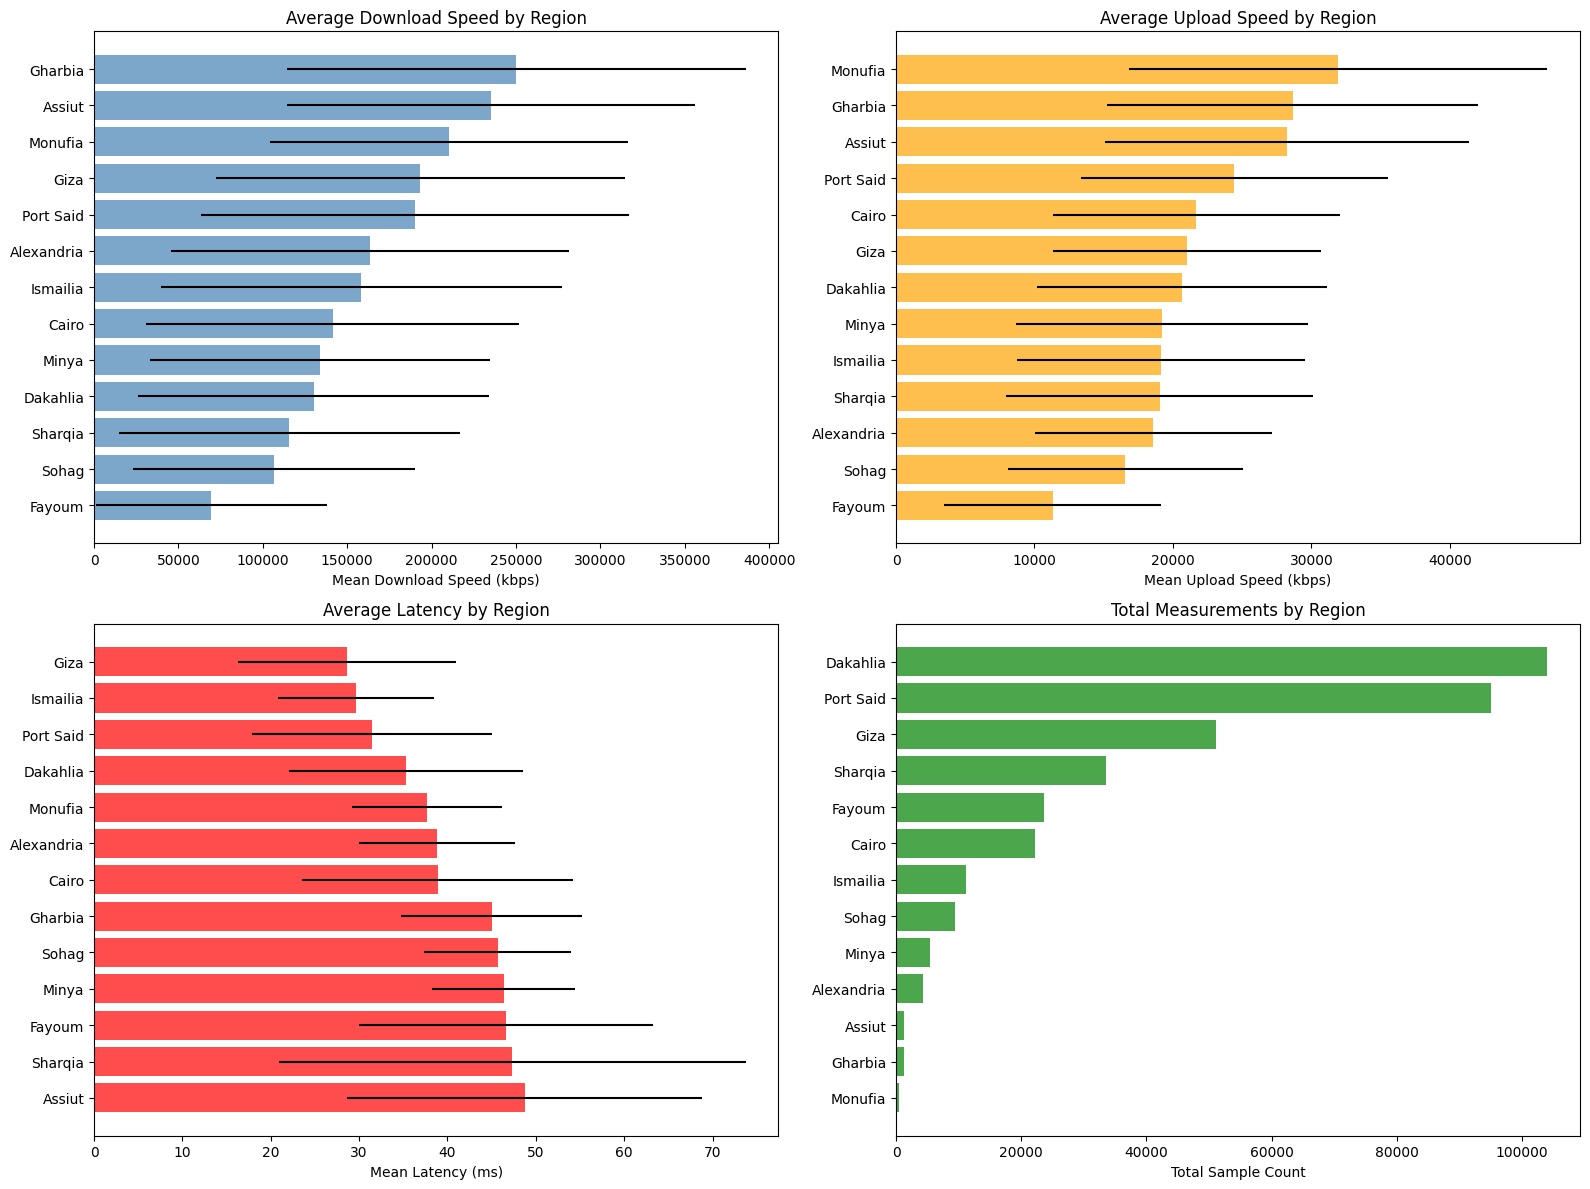

In [7]:
# Performance metrics by region
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Download speed by region
region_download = df_filtered.groupby('region')['mean_download_kbps'].agg(['mean', 'std']).sort_values('mean', ascending=True)
axes[0, 0].barh(region_download.index, region_download['mean'], xerr=region_download['std'], alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('Mean Download Speed (kbps)')
axes[0, 0].set_title('Average Download Speed by Region')

# Upload speed by region
region_upload = df_filtered.groupby('region')['mean_upload_kbps'].agg(['mean', 'std']).sort_values('mean', ascending=True)
axes[0, 1].barh(region_upload.index, region_upload['mean'], xerr=region_upload['std'], alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Mean Upload Speed (kbps)')
axes[0, 1].set_title('Average Upload Speed by Region')

# Latency by region
region_latency = df_filtered.groupby('region')['mean_latency_ms'].agg(['mean', 'std']).sort_values('mean', ascending=False)
axes[1, 0].barh(region_latency.index, region_latency['mean'], xerr=region_latency['std'], alpha=0.7, color='red')
axes[1, 0].set_xlabel('Mean Latency (ms)')
axes[1, 0].set_title('Average Latency by Region')

# Sample count by region
region_samples = df_filtered.groupby('region')['sample_count'].sum().sort_values(ascending=True)
axes[1, 1].barh(region_samples.index, region_samples.values, alpha=0.7, color='green')
axes[1, 1].set_xlabel('Total Sample Count')
axes[1, 1].set_title('Total Measurements by Region')

plt.tight_layout()
plt.savefig('outputs/performance_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

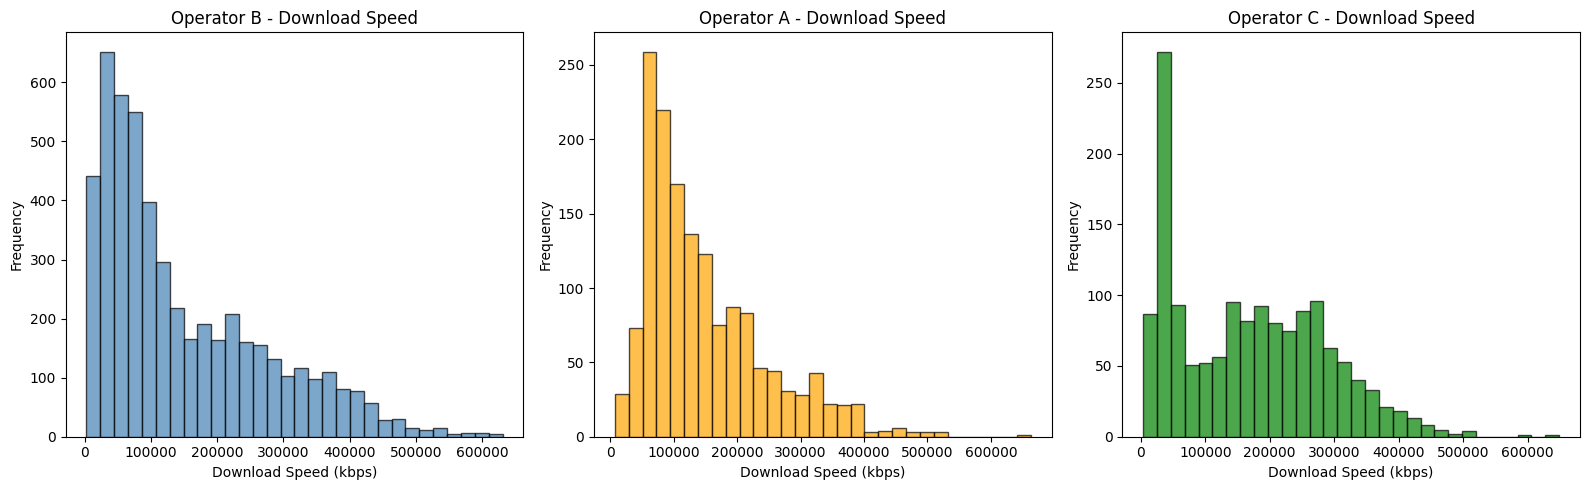

In [8]:
# Performance by carrier
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['steelblue', 'orange', 'green']
carriers = df_filtered['carrier_name'].unique()

for i, (carrier, color) in enumerate(zip(carriers, colors[:len(carriers)])):
    carrier_data = df_filtered[df_filtered['carrier_name'] == carrier]
    axes[i].hist(carrier_data['mean_download_kbps'], bins=30, alpha=0.7, color=color, edgecolor='black')
    axes[i].set_xlabel('Download Speed (kbps)')
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'{carrier} - Download Speed')

plt.tight_layout()
plt.savefig('outputs/performance_by_carrier.png', dpi=150, bbox_inches='tight')
plt.show()

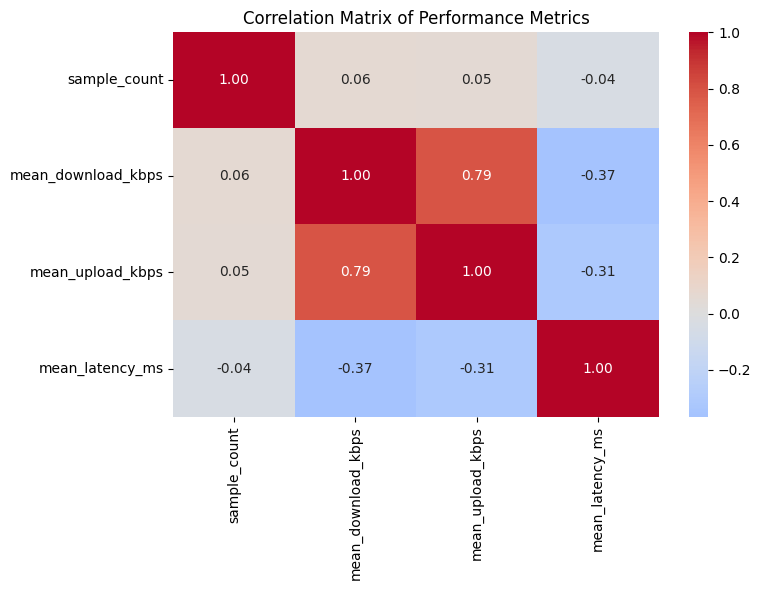

In [9]:
# Correlation matrix
numeric_cols = ['sample_count', 'mean_download_kbps', 'mean_upload_kbps', 'mean_latency_ms']

corr_matrix = df_filtered[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Performance Metrics')
plt.tight_layout()
plt.savefig('outputs/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

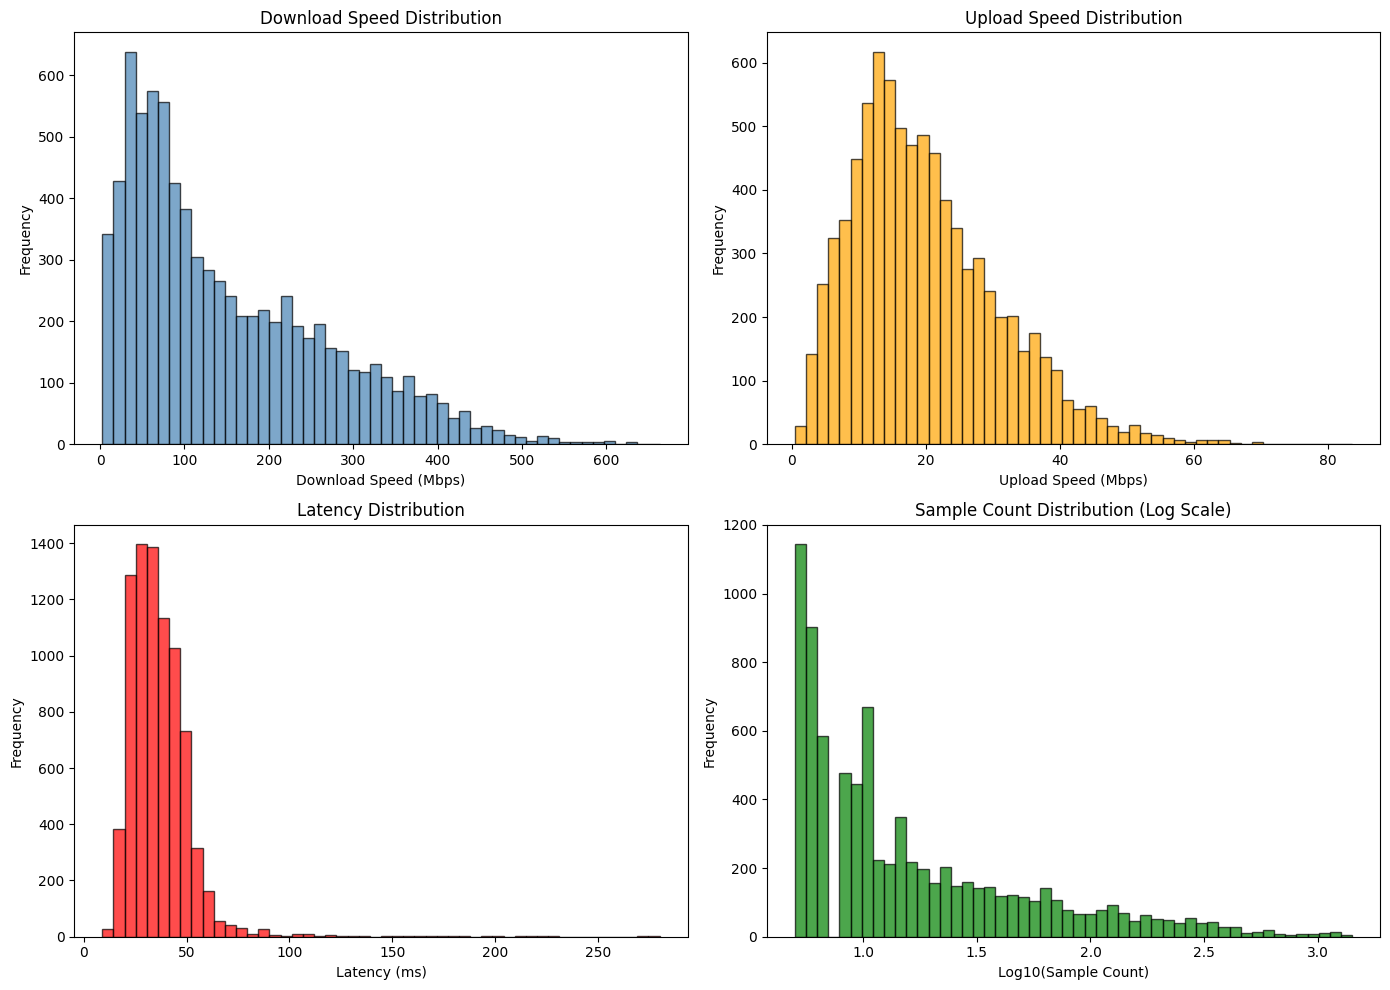

In [10]:
# KPI distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(df_filtered['mean_download_kbps']/1000, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('Download Speed (Mbps)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Download Speed Distribution')

axes[0, 1].hist(df_filtered['mean_upload_kbps']/1000, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Upload Speed (Mbps)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Upload Speed Distribution')

axes[1, 0].hist(df_filtered['mean_latency_ms'], bins=50, edgecolor='black', alpha=0.7, color='red')
axes[1, 0].set_xlabel('Latency (ms)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Latency Distribution')

axes[1, 1].hist(np.log10(df_filtered['sample_count']), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].set_xlabel('Log10(Sample Count)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Sample Count Distribution (Log Scale)')

plt.tight_layout()
plt.savefig('outputs/kpi_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

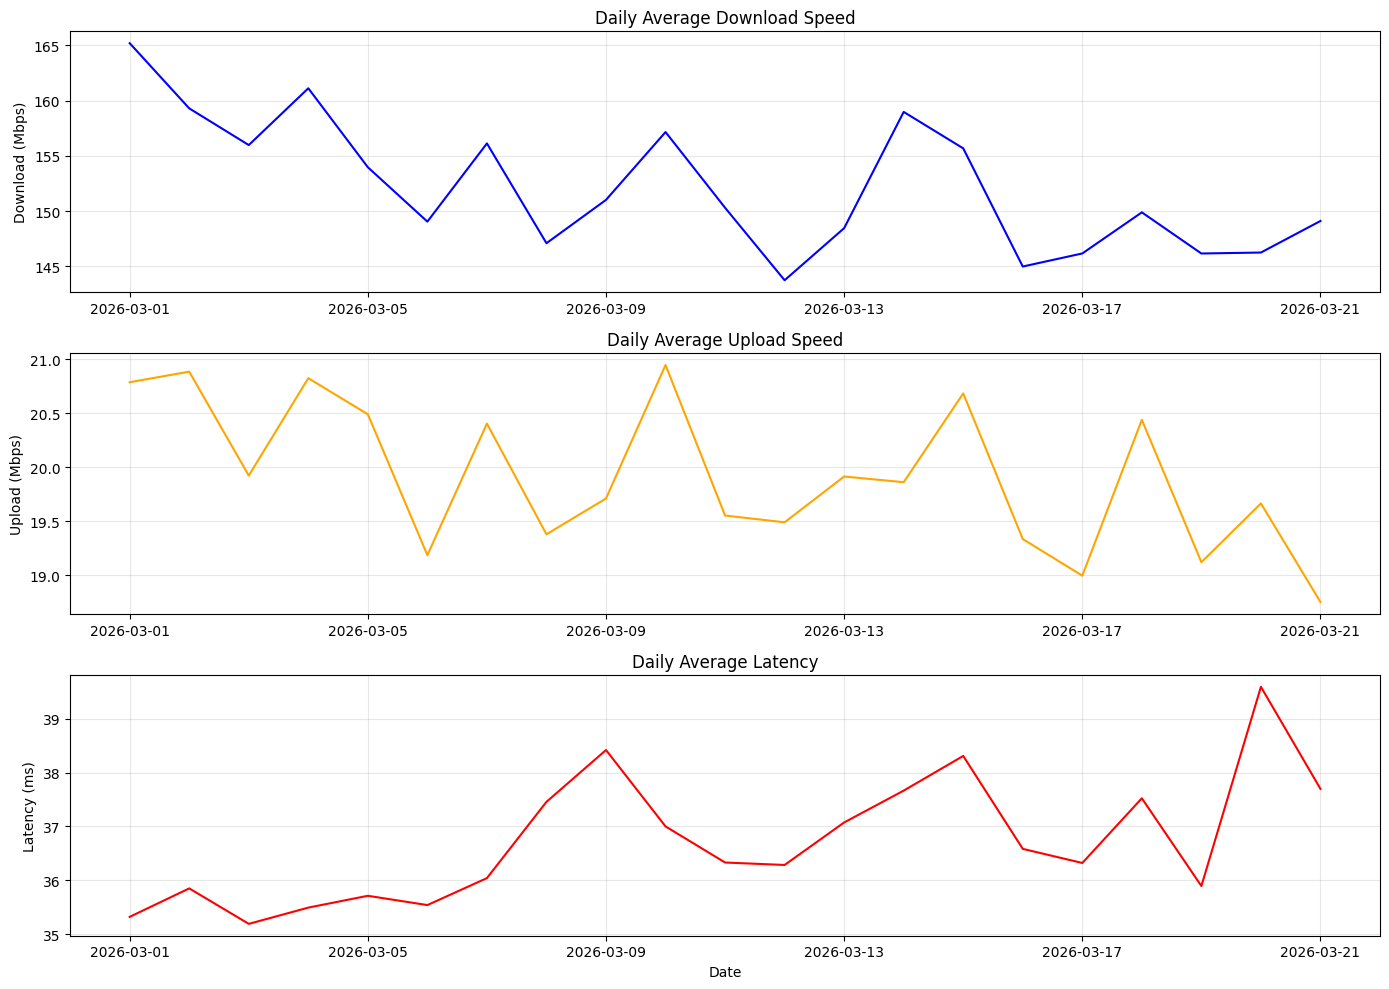

In [11]:
# Daily trends
daily_avg = df_filtered.groupby('aggregate_date').agg({
    'mean_download_kbps': 'mean',
    'mean_upload_kbps': 'mean',
    'mean_latency_ms': 'mean'
}).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(daily_avg['aggregate_date'], daily_avg['mean_download_kbps']/1000, 'b-', linewidth=1.5)
axes[0].set_ylabel('Download (Mbps)')
axes[0].set_title('Daily Average Download Speed')
axes[0].grid(True, alpha=0.3)

axes[1].plot(daily_avg['aggregate_date'], daily_avg['mean_upload_kbps']/1000, 'orange', linewidth=1.5)
axes[1].set_ylabel('Upload (Mbps)')
axes[1].set_title('Daily Average Upload Speed')
axes[1].grid(True, alpha=0.3)

axes[2].plot(daily_avg['aggregate_date'], daily_avg['mean_latency_ms'], 'r-', linewidth=1.5)
axes[2].set_ylabel('Latency (ms)')
axes[2].set_xlabel('Date')
axes[2].set_title('Daily Average Latency')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/daily_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Anomaly Detection Models

In [12]:
# Prepare data for anomaly detection
features = ['mean_download_kbps', 'mean_upload_kbps', 'mean_latency_ms']

X = df_filtered[features].copy()
X = X.fillna(X.median())

# StandardScaler for Isolation Forest and OC-SVM
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# MinMaxScaler for Autoencoder (output between 0 and 1)
scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(X)

print(f"Data shape for anomaly detection: {X_scaled.shape}")

Data shape for anomaly detection: (8086, 3)


### 4.1 Isolation Forest

In [13]:
# Train Isolation Forest
print("Training Isolation Forest...")
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_scaled)

# Predict anomalies (-1 for anomaly, 1 for normal)
iso_predictions = iso_forest.predict(X_scaled)
iso_scores = iso_forest.decision_function(X_scaled)

# Store results
df_results = df_filtered.copy()
df_results['iso_anomaly'] = (iso_predictions == -1).astype(int)
df_results['iso_score'] = iso_scores

print(f"Isolation Forest Results:")
print(f"  Total anomalies detected: {df_results['iso_anomaly'].sum()}")
print(f"  Anomaly rate: {df_results['iso_anomaly'].mean()*100:.2f}%")

Training Isolation Forest...


Isolation Forest Results:
  Total anomalies detected: 405
  Anomaly rate: 5.01%


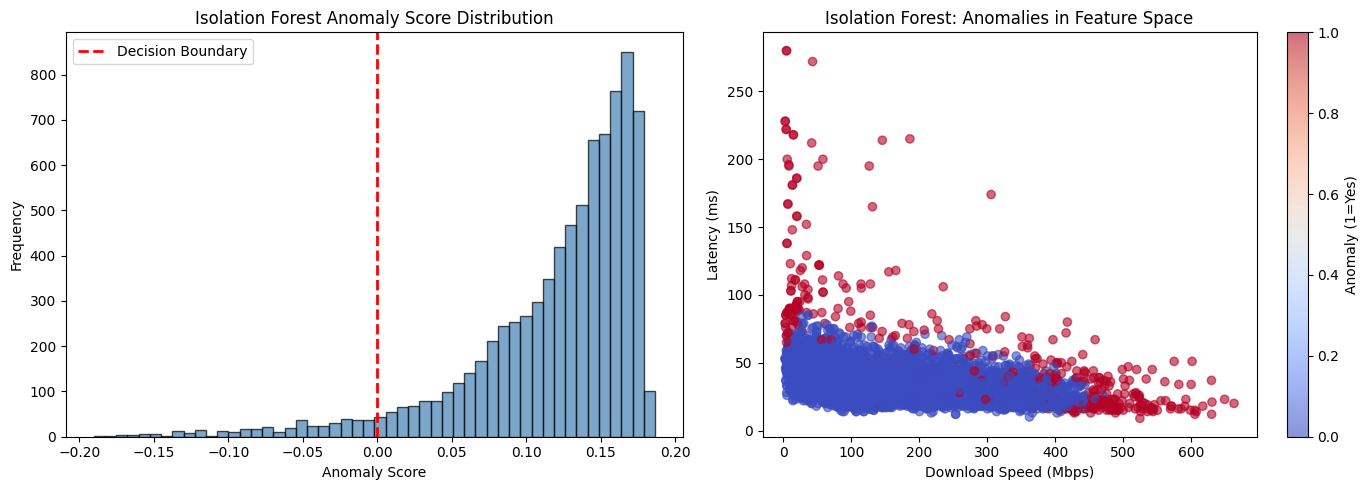

In [14]:
# Visualize Isolation Forest results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(iso_scores, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Decision Boundary')
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Isolation Forest Anomaly Score Distribution')
axes[0].legend()

scatter = axes[1].scatter(df_results['mean_download_kbps']/1000, 
                          df_results['mean_latency_ms'],
                          c=df_results['iso_anomaly'], 
                          cmap='coolwarm', alpha=0.6)
axes[1].set_xlabel('Download Speed (Mbps)')
axes[1].set_ylabel('Latency (ms)')
axes[1].set_title('Isolation Forest: Anomalies in Feature Space')
plt.colorbar(scatter, ax=axes[1], label='Anomaly (1=Yes)')

plt.tight_layout()
plt.savefig('outputs/isolation_forest_results.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 One-Class SVM (OC-SVM)

In [15]:
# Train One-Class SVM
print("Training One-Class SVM...")

# Use a sample for training (OC-SVM is computationally expensive)
sample_size = min(5000, len(X_scaled))
sample_indices = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_indices]

ocsvm = OneClassSVM(
    kernel='rbf',
    nu=0.05,
    gamma='scale'
)
ocsvm.fit(X_sample)

# Predict anomalies
ocsvm_predictions = ocsvm.predict(X_scaled)
ocsvm_scores = ocsvm.decision_function(X_scaled)

df_results['ocsvm_anomaly'] = (ocsvm_predictions == -1).astype(int)
df_results['ocsvm_score'] = ocsvm_scores

print(f"One-Class SVM Results:")
print(f"  Total anomalies detected: {df_results['ocsvm_anomaly'].sum()}")
print(f"  Anomaly rate: {df_results['ocsvm_anomaly'].mean()*100:.2f}%")

Training One-Class SVM...


One-Class SVM Results:
  Total anomalies detected: 407
  Anomaly rate: 5.03%


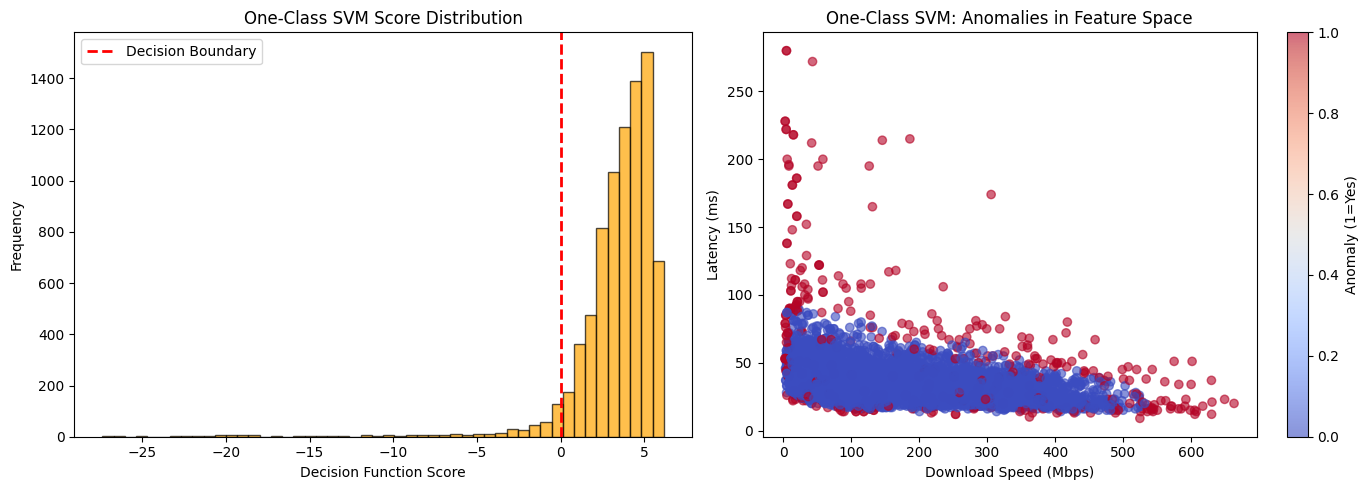

In [16]:
# Visualize OC-SVM results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ocsvm_scores, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Decision Boundary')
axes[0].set_xlabel('Decision Function Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('One-Class SVM Score Distribution')
axes[0].legend()

scatter = axes[1].scatter(df_results['mean_download_kbps']/1000, 
                          df_results['mean_latency_ms'],
                          c=df_results['ocsvm_anomaly'], 
                          cmap='coolwarm', alpha=0.6)
axes[1].set_xlabel('Download Speed (Mbps)')
axes[1].set_ylabel('Latency (ms)')
axes[1].set_title('One-Class SVM: Anomalies in Feature Space')
plt.colorbar(scatter, ax=axes[1], label='Anomaly (1=Yes)')

plt.tight_layout()
plt.savefig('outputs/ocsvm_results.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Autoencoder (PyTorch)

In [17]:
# Define PyTorch Autoencoder
class Autoencoder(nn.Module):
    """
    PyTorch Autoencoder for Anomaly Detection
    
    Architecture:
    - Encoder: input -> 16 -> 8 -> 2 (bottleneck)
    - Decoder: 2 -> 8 -> 16 -> output
    """
    def __init__(self, input_dim, encoding_dim=2):
        super(Autoencoder, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, encoding_dim),
            nn.ReLU()
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

print("Autoencoder model defined!")

Autoencoder model defined!


In [18]:
# Prepare PyTorch data
X_tensor = torch.FloatTensor(X_mm)
dataset = TensorDataset(X_tensor, X_tensor)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

# Initialize model
autoencoder = Autoencoder(X_mm.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)

print(autoencoder)
print(f"\nTotal parameters: {sum(p.numel() for p in autoencoder.parameters())}")

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=2, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=3, bias=True)
    (5): Sigmoid()
  )
)

Total parameters: 437


In [19]:
# Train Autoencoder
print("Training PyTorch Autoencoder...")

num_epochs = 50
train_losses = []
val_losses = []

# Split for validation
X_train, X_val = train_test_split(X_mm, test_size=0.2, random_state=42)
X_train_tensor = torch.FloatTensor(X_train).to(device)
X_val_tensor = torch.FloatTensor(X_val).to(device)

autoencoder.train()

for epoch in range(num_epochs):
    train_loss = 0
    for batch_x, _ in dataloader:
        batch_x = batch_x.to(device)
        
        outputs = autoencoder(batch_x)
        loss = criterion(outputs, batch_x)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    # Validation
    autoencoder.eval()
    with torch.no_grad():
        val_outputs = autoencoder(X_val_tensor)
        val_loss = criterion(val_outputs, X_val_tensor).item()
    autoencoder.train()
    
    avg_train_loss = train_loss / len(dataloader)
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"  Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {val_loss:.6f}")

print("\nAutoencoder training completed!")

Training PyTorch Autoencoder...


  Epoch [10/50], Train Loss: 0.008622, Val Loss: 0.007239


  Epoch [20/50], Train Loss: 0.002944, Val Loss: 0.003304


  Epoch [30/50], Train Loss: 0.002740, Val Loss: 0.003098


  Epoch [40/50], Train Loss: 0.002672, Val Loss: 0.003002


  Epoch [50/50], Train Loss: 0.002590, Val Loss: 0.002938

Autoencoder training completed!


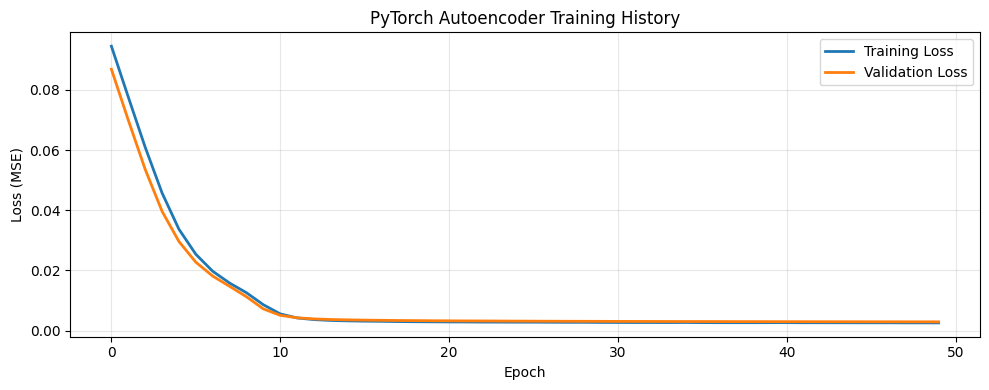

In [20]:
# Plot training history
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('PyTorch Autoencoder Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/autoencoder_training.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Calculate reconstruction error for anomaly detection
autoencoder.eval()
with torch.no_grad():
    X_tensor_device = X_tensor.to(device)
    reconstructions = autoencoder(X_tensor_device).cpu().numpy()

mse = np.mean(np.power(X_mm - reconstructions, 2), axis=1)

# Determine threshold (95th percentile)
threshold = np.percentile(mse, 95)

df_results['ae_mse'] = mse
df_results['ae_anomaly'] = (mse > threshold).astype(int)
df_results['ae_threshold'] = threshold

print(f"PyTorch Autoencoder Results:")
print(f"  Reconstruction error threshold: {threshold:.6f}")
print(f"  Total anomalies detected: {df_results['ae_anomaly'].sum()}")
print(f"  Anomaly rate: {df_results['ae_anomaly'].mean()*100:.2f}%")

PyTorch Autoencoder Results:
  Reconstruction error threshold: 0.008656
  Total anomalies detected: 405
  Anomaly rate: 5.01%


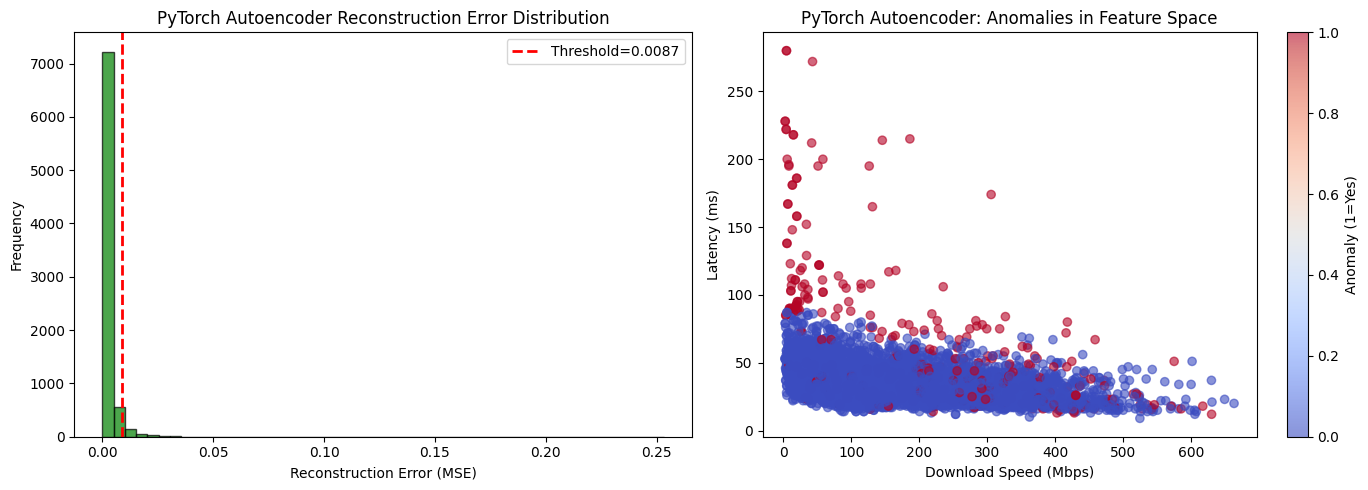

In [22]:
# Visualize Autoencoder results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(mse, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0].axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold={threshold:.4f}')
axes[0].set_xlabel('Reconstruction Error (MSE)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('PyTorch Autoencoder Reconstruction Error Distribution')
axes[0].legend()

scatter = axes[1].scatter(df_results['mean_download_kbps']/1000, 
                          df_results['mean_latency_ms'],
                          c=df_results['ae_anomaly'], 
                          cmap='coolwarm', alpha=0.6)
axes[1].set_xlabel('Download Speed (Mbps)')
axes[1].set_ylabel('Latency (ms)')
axes[1].set_title('PyTorch Autoencoder: Anomalies in Feature Space')
plt.colorbar(scatter, ax=axes[1], label='Anomaly (1=Yes)')

plt.tight_layout()
plt.savefig('outputs/autoencoder_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Model Comparison and Ensemble Results

In [23]:
# Compare the three methods
methods = ['Isolation Forest', 'One-Class SVM', 'Autoencoder (PyTorch)']
anomaly_cols = ['iso_anomaly', 'ocsvm_anomaly', 'ae_anomaly']

anomaly_counts = [df_results[col].sum() for col in anomaly_cols]
anomaly_rates = [df_results[col].mean()*100 for col in anomaly_cols]

comparison_df = pd.DataFrame({
    'Method': methods,
    'Anomalies Detected': anomaly_counts,
    'Anomaly Rate (%)': [f"{r:.2f}" for r in anomaly_rates]
})

print("Method Comparison Summary:")
print(comparison_df.to_string(index=False))

# Save comparison
comparison_df.to_csv('outputs/method_comparison.csv', index=False)

Method Comparison Summary:
               Method  Anomalies Detected Anomaly Rate (%)
     Isolation Forest                 405             5.01
        One-Class SVM                 407             5.03
Autoencoder (PyTorch)                 405             5.01


In [24]:
# Calculate ensemble agreement
df_results['methods_agree'] = df_results['iso_anomaly'] + df_results['ocsvm_anomaly'] + df_results['ae_anomaly']

print("\nAnomaly Agreement Analysis:")
print(f"  Records flagged by all 3 methods: {(df_results['methods_agree'] == 3).sum()}")
print(f"  Records flagged by exactly 2 methods: {(df_results['methods_agree'] == 2).sum()}")
print(f"  Records flagged by exactly 1 method: {(df_results['methods_agree'] == 1).sum()}")
print(f"  Records not flagged by any method: {(df_results['methods_agree'] == 0).sum()}")

# Create high-confidence anomaly flag (at least 2 methods agree)
df_results['high_confidence_anomaly'] = (df_results['methods_agree'] >= 2).astype(int)


Anomaly Agreement Analysis:
  Records flagged by all 3 methods: 174
  Records flagged by exactly 2 methods: 175
  Records flagged by exactly 1 method: 345
  Records not flagged by any method: 7392


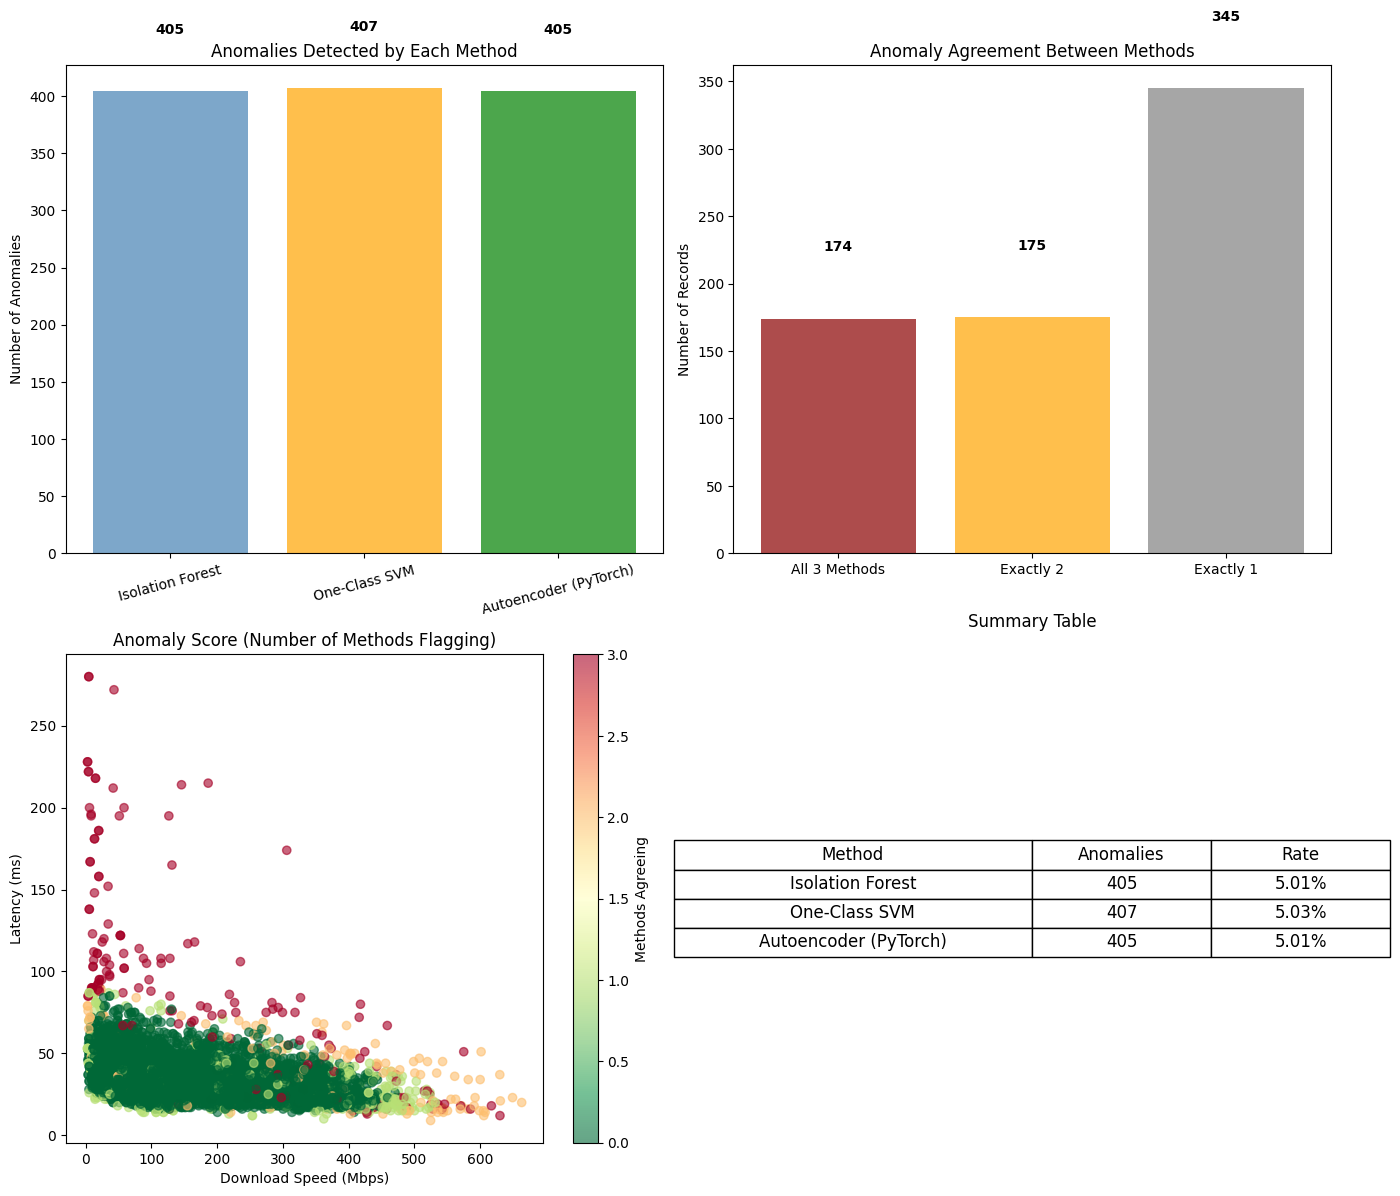

In [25]:
# Visualize method comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Bar chart of anomaly counts
colors = ['steelblue', 'orange', 'green']
bars = axes[0, 0].bar(methods, anomaly_counts, color=colors, alpha=0.7)
axes[0, 0].set_ylabel('Number of Anomalies')
axes[0, 0].set_title('Anomalies Detected by Each Method')
axes[0, 0].tick_params(axis='x', rotation=15)
for bar, count in zip(bars, anomaly_counts):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
                    str(count), ha='center', fontweight='bold')

# Agreement breakdown
agreement_counts = [
    (df_results['methods_agree'] == 3).sum(),
    (df_results['methods_agree'] == 2).sum(),
    (df_results['methods_agree'] == 1).sum()
]
agreement_labels = ['All 3 Methods', 'Exactly 2', 'Exactly 1']
bars = axes[0, 1].bar(agreement_labels, agreement_counts, color=['darkred', 'orange', 'gray'], alpha=0.7)
axes[0, 1].set_ylabel('Number of Records')
axes[0, 1].set_title('Anomaly Agreement Between Methods')
for bar, count in zip(bars, agreement_counts):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                    str(count), ha='center', fontweight='bold')

# Feature space visualization
scatter = axes[1, 0].scatter(df_results['mean_download_kbps']/1000, 
                              df_results['mean_latency_ms'],
                              c=df_results['methods_agree'], 
                              cmap='RdYlGn_r', alpha=0.6, vmin=0, vmax=3)
axes[1, 0].set_xlabel('Download Speed (Mbps)')
axes[1, 0].set_ylabel('Latency (ms)')
axes[1, 0].set_title('Anomaly Score (Number of Methods Flagging)')
plt.colorbar(scatter, ax=axes[1, 0], label='Methods Agreeing')

# Method comparison table
axes[1, 1].axis('off')
table_data = [[m, str(c), f"{r:.2f}%"] for m, c, r in zip(methods, anomaly_counts, anomaly_rates)]
table = axes[1, 1].table(cellText=table_data, colLabels=['Method', 'Anomalies', 'Rate'],
                         loc='center', cellLoc='center',
                         colWidths=[0.5, 0.25, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)
axes[1, 1].set_title('Summary Table', pad=20)

plt.tight_layout()
plt.savefig('outputs/method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Answering Project Questions

In [26]:
# Q1: Which regions show the most variable download speed?
print("="*60)
print("Q1: Which regions show the most variable download speed?")
print("="*60)

regional_stats = df_results.groupby('region').agg({
    'mean_download_kbps': ['mean', 'std', 'count']
})
regional_stats.columns = ['mean_download', 'std_download', 'count']
regional_stats['cv'] = regional_stats['std_download'] / regional_stats['mean_download'] * 100
regional_stats = regional_stats.sort_values('cv', ascending=False).reset_index()

print("\nRegions with Most Variable Download Speed (by Coefficient of Variation):")
print(regional_stats.head(5).to_string(index=False))

# Save Q1 results
regional_stats.to_csv('outputs/q1_regional_variability.csv', index=False)

Q1: Which regions show the most variable download speed?

Regions with Most Variable Download Speed (by Coefficient of Variation):
  region  mean_download  std_download  count        cv
  Fayoum   69487.248366  68503.957375   1071 98.584933
 Sharqia  115732.955090 100942.993263    668 87.220613
Dakahlia  130243.815842 103952.777713   1010 79.813984
   Sohag  106872.969849  83525.794471    199 78.154275
   Cairo  141506.759152 110565.119700    519 78.134161


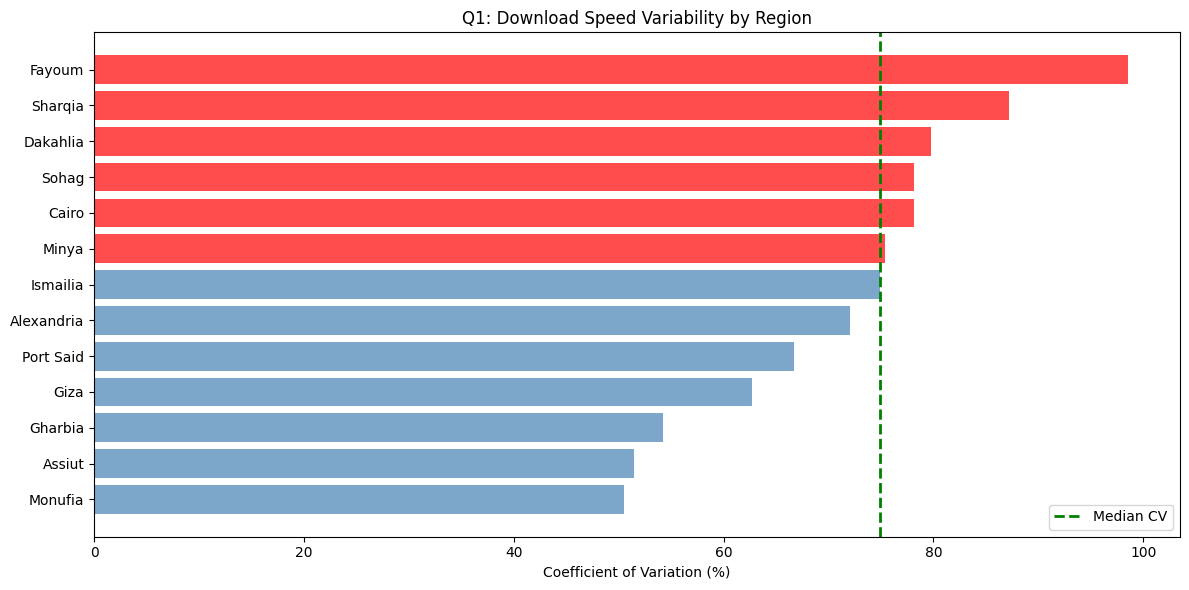

In [27]:
# Visualize Q1
fig, ax = plt.subplots(figsize=(12, 6))
q1_plot = regional_stats.sort_values('cv', ascending=True)
colors = ['red' if cv > q1_plot['cv'].median() else 'steelblue' for cv in q1_plot['cv']]
ax.barh(q1_plot['region'], q1_plot['cv'], color=colors, alpha=0.7)
ax.set_xlabel('Coefficient of Variation (%)')
ax.set_title('Q1: Download Speed Variability by Region')
ax.axvline(x=q1_plot['cv'].median(), color='green', linestyle='--', linewidth=2, label='Median CV')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/q1_region_variability.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# Q2: Which specific days show abnormal network behavior?
print("="*60)
print("Q2: Which days show abnormal network behavior across regions?")
print("="*60)

daily_anomalies = df_results.groupby('aggregate_date').agg({
    'iso_anomaly': 'sum',
    'ocsvm_anomaly': 'sum',
    'ae_anomaly': 'sum',
    'methods_agree': 'sum',
    'high_confidence_anomaly': 'sum',
    'mean_download_kbps': 'mean',
    'mean_latency_ms': 'mean'
}).reset_index()

daily_anomalies = daily_anomalies.sort_values('high_confidence_anomaly', ascending=False)

print("\nDays with Most High-Confidence Anomalies:")
print(daily_anomalies[['aggregate_date', 'high_confidence_anomaly', 'methods_agree', 'mean_download_kbps', 'mean_latency_ms']].head(10).to_string(index=False))

# Save Q2 results
daily_anomalies.to_csv('outputs/q2_daily_anomalies.csv', index=False)

Q2: Which days show abnormal network behavior across regions?

Days with Most High-Confidence Anomalies:
aggregate_date  high_confidence_anomaly  methods_agree  mean_download_kbps  mean_latency_ms
    2026-03-20                       32            104       146254.477922        39.589610
    2026-03-08                       25             73       147098.887435        37.455497
    2026-03-18                       22             70       149893.314578        37.521739
    2026-03-10                       22             68       157161.828645        37.000000
    2026-03-09                       21             62       151020.459103        38.416887
    2026-03-02                       20             71       159306.140000        35.850000
    2026-03-15                       19             62       155686.153639        38.307278
    2026-03-19                       19             61       146167.484848        35.893939
    2026-03-07                       18             70       156133

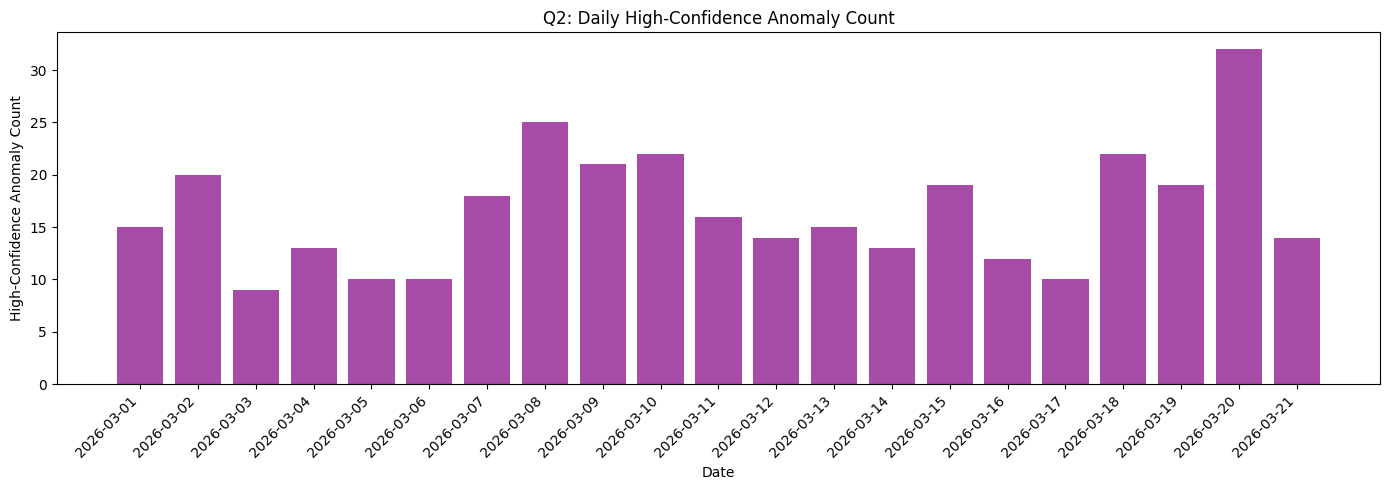

In [29]:
# Visualize Q2
fig, ax = plt.subplots(figsize=(14, 5))
daily_sorted = daily_anomalies.sort_values('aggregate_date')
ax.bar(daily_sorted['aggregate_date'].dt.strftime('%Y-%m-%d'), 
       daily_sorted['high_confidence_anomaly'], color='purple', alpha=0.7)
ax.set_xlabel('Date')
ax.set_ylabel('High-Confidence Anomaly Count')
ax.set_title('Q2: Daily High-Confidence Anomaly Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/q2_daily_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Q3: Which carrier shows the most consistent performance?
print("="*60)
print("Q3: Which carrier shows the most consistent performance?")
print("="*60)

carrier_stats = df_results.groupby('carrier_name').agg({
    'mean_download_kbps': ['mean', 'std'],
    'mean_upload_kbps': ['mean', 'std'],
    'mean_latency_ms': ['mean', 'std'],
    'high_confidence_anomaly': ['sum', 'mean'],
    'iso_anomaly': 'sum',
    'ocsvm_anomaly': 'sum',
    'ae_anomaly': 'sum'
})

carrier_stats.columns = ['_'.join(col) for col in carrier_stats.columns]
carrier_stats = carrier_stats.reset_index()

# Calculate CV for each metric
carrier_stats['download_cv'] = carrier_stats['mean_download_kbps_std'] / carrier_stats['mean_download_kbps_mean'] * 100
carrier_stats['upload_cv'] = carrier_stats['mean_upload_kbps_std'] / carrier_stats['mean_upload_kbps_mean'] * 100
carrier_stats['latency_cv'] = carrier_stats['mean_latency_ms_std'] / carrier_stats['mean_latency_ms_mean'] * 100
carrier_stats['anomaly_rate'] = carrier_stats['high_confidence_anomaly_mean'] * 100

print("\nCarrier Performance Summary:")
print(carrier_stats[['carrier_name', 'mean_download_kbps_mean', 'download_cv', 'anomaly_rate']].to_string(index=False))

# Save Q3 results
carrier_stats.to_csv('outputs/q3_carrier_consistency.csv', index=False)

Q3: Which carrier shows the most consistent performance?

Carrier Performance Summary:
carrier_name  mean_download_kbps_mean  download_cv  anomaly_rate
  Operator A            147527.269055    65.306482      1.498371
  Operator B            148672.500690    84.151818      4.833300
  Operator C            168915.420378    69.282105      5.465587


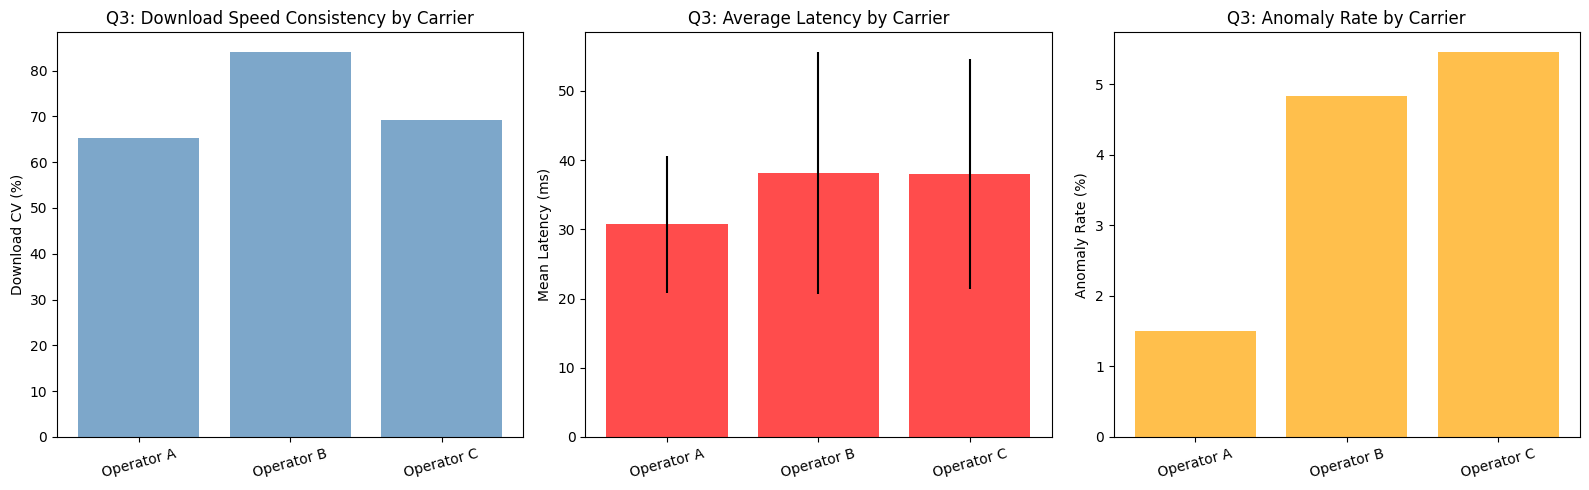

In [31]:
# Visualize Q3
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Download speed CV
axes[0].bar(carrier_stats['carrier_name'], carrier_stats['download_cv'], color='steelblue', alpha=0.7)
axes[0].set_ylabel('Download CV (%)')
axes[0].set_title('Q3: Download Speed Consistency by Carrier')
axes[0].tick_params(axis='x', rotation=15)

# Latency
axes[1].bar(carrier_stats['carrier_name'], carrier_stats['mean_latency_ms_mean'], 
            yerr=carrier_stats['mean_latency_ms_std'], color='red', alpha=0.7)
axes[1].set_ylabel('Mean Latency (ms)')
axes[1].set_title('Q3: Average Latency by Carrier')
axes[1].tick_params(axis='x', rotation=15)

# Anomaly rate
axes[2].bar(carrier_stats['carrier_name'], carrier_stats['anomaly_rate'], color='orange', alpha=0.7)
axes[2].set_ylabel('Anomaly Rate (%)')
axes[2].set_title('Q3: Anomaly Rate by Carrier')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('outputs/q3_carrier_consistency.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# Q4: Does LTE vs 5G show different anomaly patterns?
print("="*60)
print("Q4: LTE vs 5G Anomaly Patterns")
print("="*60)

tech_stats = df_results.groupby('technology_type').agg({
    'mean_download_kbps': ['mean', 'std'],
    'mean_upload_kbps': ['mean', 'std'],
    'mean_latency_ms': ['mean', 'std'],
    'high_confidence_anomaly': ['sum', 'mean', 'count'],
    'iso_anomaly': 'sum',
    'ocsvm_anomaly': 'sum',
    'ae_anomaly': 'sum'
})

tech_stats.columns = ['_'.join(col) for col in tech_stats.columns]
tech_stats = tech_stats.reset_index()
tech_stats['anomaly_rate'] = tech_stats['high_confidence_anomaly_mean'] * 100

print("\nTechnology Performance Summary:")
print(tech_stats[['technology_type', 'mean_download_kbps_mean', 'mean_latency_ms_mean', 'anomaly_rate']].to_string(index=False))

# Save Q4 results
tech_stats.to_csv('outputs/q4_lte_vs_5g.csv', index=False)

Q4: LTE vs 5G Anomaly Patterns

Technology Performance Summary:
technology_type  mean_download_kbps_mean  mean_latency_ms_mean  anomaly_rate
             5G            301105.735005             30.401854      8.833152
            LTE             60748.197605             39.679266      2.432635
      Multi-RAT            144095.199721             37.732961      3.407821


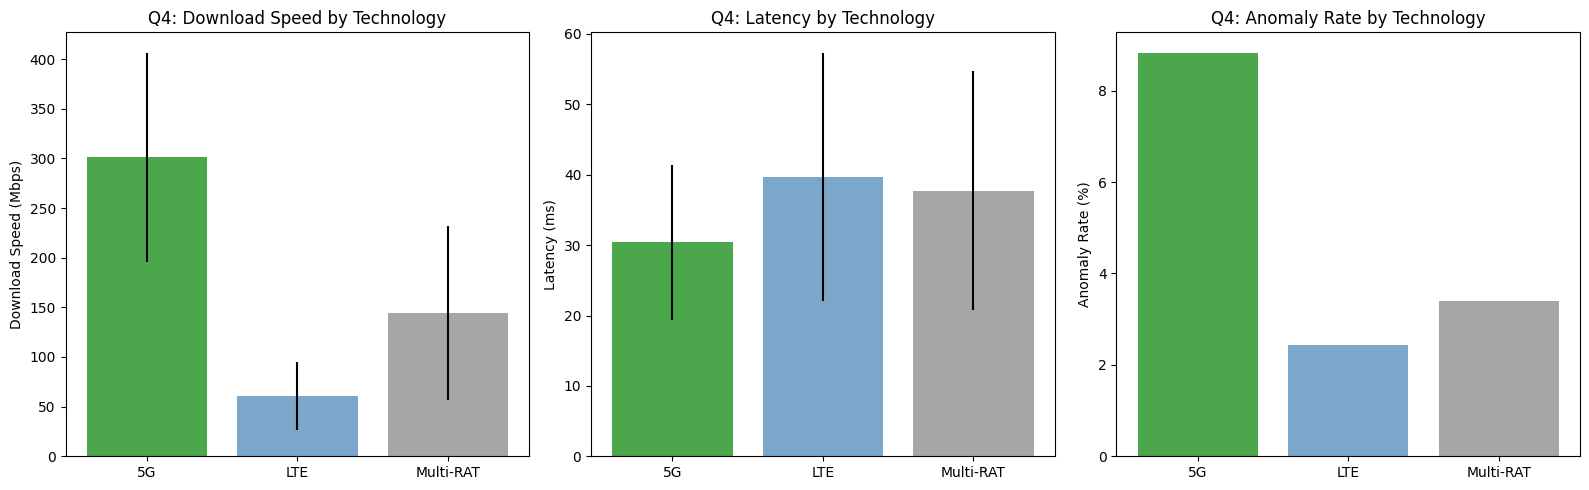

In [33]:
# Visualize Q4
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

tech_colors = {'LTE': 'steelblue', '5G': 'green'}
colors = [tech_colors.get(t, 'gray') for t in tech_stats['technology_type']]

axes[0].bar(tech_stats['technology_type'], tech_stats['mean_download_kbps_mean']/1000, 
            yerr=tech_stats['mean_download_kbps_std']/1000, color=colors, alpha=0.7)
axes[0].set_ylabel('Download Speed (Mbps)')
axes[0].set_title('Q4: Download Speed by Technology')

axes[1].bar(tech_stats['technology_type'], tech_stats['mean_latency_ms_mean'], 
            yerr=tech_stats['mean_latency_ms_std'], color=colors, alpha=0.7)
axes[1].set_ylabel('Latency (ms)')
axes[1].set_title('Q4: Latency by Technology')

axes[2].bar(tech_stats['technology_type'], tech_stats['anomaly_rate'], color=colors, alpha=0.7)
axes[2].set_ylabel('Anomaly Rate (%)')
axes[2].set_title('Q4: Anomaly Rate by Technology')

plt.tight_layout()
plt.savefig('outputs/q4_lte_vs_5g.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# Q5: Which are the top 5 worst performing region-carrier combinations?
print("="*60)
print("Q5: Top 5 Worst Performing Region-Carrier Combinations")
print("="*60)

combo_stats = df_results.groupby(['region', 'carrier_name']).agg({
    'mean_download_kbps': 'mean',
    'mean_latency_ms': 'mean',
    'high_confidence_anomaly': ['sum', 'mean'],
    'methods_agree': 'sum'
})

combo_stats.columns = ['_'.join(col) for col in combo_stats.columns]
combo_stats = combo_stats.reset_index()
combo_stats = combo_stats.sort_values('high_confidence_anomaly_sum', ascending=False)

print("\nTop 5 Worst Performing Combinations:")
top5_worst = combo_stats.head(5)
print(top5_worst.to_string(index=False))

# Save Q5 results
combo_stats.to_csv('outputs/q5_region_carrier_combinations.csv', index=False)

Q5: Top 5 Worst Performing Region-Carrier Combinations

Top 5 Worst Performing Combinations:
   region carrier_name  mean_download_kbps_mean  mean_latency_ms_mean  high_confidence_anomaly_sum  high_confidence_anomaly_mean  methods_agree_sum
Port Said   Operator B            192846.949367             32.434599                           53                      0.074543                167
     Giza   Operator B            221221.480505             24.326835                           51                      0.058486                203
  Sharqia   Operator B            110410.781327             52.356265                           35                      0.085995                105
   Fayoum   Operator B             67186.040340             46.936306                           28                      0.029724                 95
     Giza   Operator C            184643.473786             34.603883                           26                      0.050485                 97


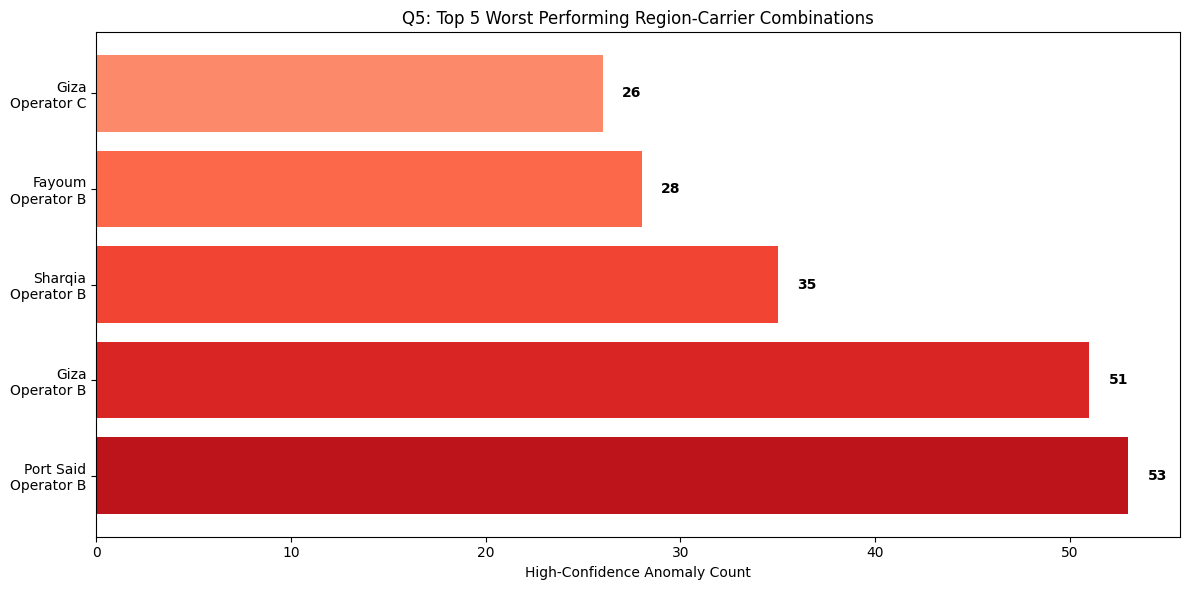

In [35]:
# Visualize Q5
fig, ax = plt.subplots(figsize=(12, 6))

top5_worst['label'] = top5_worst['region'] + '\n' + top5_worst['carrier_name']
colors = plt.cm.Reds(np.linspace(0.8, 0.4, 5))

bars = ax.barh(top5_worst['label'], top5_worst['high_confidence_anomaly_sum'], color=colors)
ax.set_xlabel('High-Confidence Anomaly Count')
ax.set_title('Q5: Top 5 Worst Performing Region-Carrier Combinations')

for bar, val in zip(bars, top5_worst['high_confidence_anomaly_sum']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, str(int(val)), 
            va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/q5_top5_worst.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save Final Results for Dashboard

In [36]:
# Save the main results file
df_results.to_csv('outputs/processed_data_with_anomalies.csv', index=False)
print("Saved: outputs/processed_data_with_anomalies.csv")

# Save summary statistics
summary_stats = {
    'total_records': len(df_results),
    'total_regions': df_results['region'].nunique(),
    'total_carriers': df_results['carrier_name'].nunique(),
    'date_range_start': str(df_results['aggregate_date'].min().date()),
    'date_range_end': str(df_results['aggregate_date'].max().date()),
    'iso_anomalies': int(df_results['iso_anomaly'].sum()),
    'ocsvm_anomalies': int(df_results['ocsvm_anomaly'].sum()),
    'ae_anomalies': int(df_results['ae_anomaly'].sum()),
    'high_confidence_anomalies': int(df_results['high_confidence_anomaly'].sum()),
    'mean_download_mbps': float(df_results['mean_download_kbps'].mean() / 1000),
    'mean_upload_mbps': float(df_results['mean_upload_kbps'].mean() / 1000),
    'mean_latency_ms': float(df_results['mean_latency_ms'].mean())
}

with open('outputs/summary_stats.json', 'w') as f:
    json.dump(summary_stats, f, indent=2)
print("Saved: outputs/summary_stats.json")

Saved: outputs/processed_data_with_anomalies.csv
Saved: outputs/summary_stats.json


In [37]:
# Create anomaly log (high-confidence anomalies only)
anomaly_log = df_results[df_results['high_confidence_anomaly'] == 1][
    ['aggregate_date', 'region', 'carrier_name', 'technology_type',
     'mean_download_kbps', 'mean_upload_kbps', 'mean_latency_ms',
     'iso_anomaly', 'ocsvm_anomaly', 'ae_anomaly', 'methods_agree']
].sort_values(['aggregate_date', 'methods_agree'], ascending=[True, False])

anomaly_log.to_csv('outputs/anomaly_log.csv', index=False)
print(f"Saved: outputs/anomaly_log.csv ({len(anomaly_log)} high-confidence anomalies)")

Saved: outputs/anomaly_log.csv (349 high-confidence anomalies)


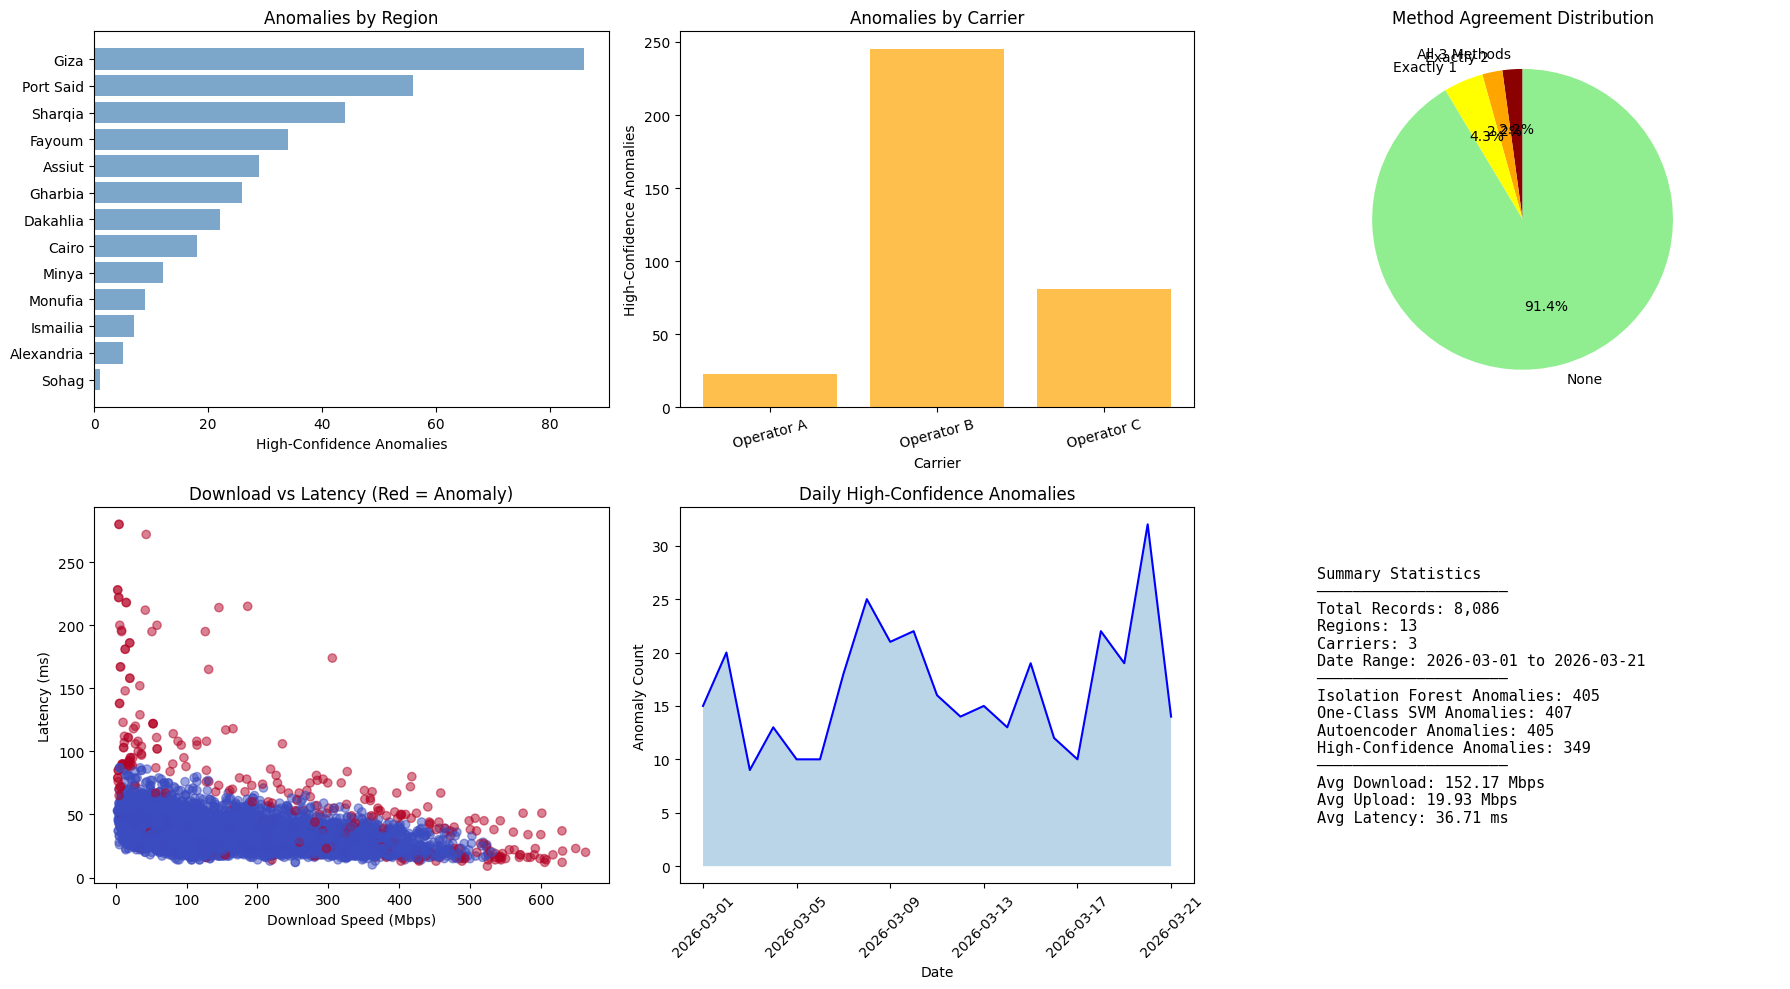

In [38]:
# Create summary visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Anomaly distribution by region
region_anomalies = df_results.groupby('region')['high_confidence_anomaly'].sum().sort_values(ascending=True)
axes[0, 0].barh(region_anomalies.index, region_anomalies.values, color='steelblue', alpha=0.7)
axes[0, 0].set_xlabel('High-Confidence Anomalies')
axes[0, 0].set_title('Anomalies by Region')

# 2. Anomaly distribution by carrier
carrier_anomalies = df_results.groupby('carrier_name')['high_confidence_anomaly'].sum()
axes[0, 1].bar(carrier_anomalies.index, carrier_anomalies.values, color='orange', alpha=0.7)
axes[0, 1].set_xlabel('Carrier')
axes[0, 1].set_ylabel('High-Confidence Anomalies')
axes[0, 1].set_title('Anomalies by Carrier')
axes[0, 1].tick_params(axis='x', rotation=15)

# 3. Method agreement pie chart
agreement_counts = [
    (df_results['methods_agree'] == 3).sum(),
    (df_results['methods_agree'] == 2).sum(),
    (df_results['methods_agree'] == 1).sum(),
    (df_results['methods_agree'] == 0).sum()
]
labels = ['All 3 Methods', 'Exactly 2', 'Exactly 1', 'None']
colors_pie = ['darkred', 'orange', 'yellow', 'lightgreen']
axes[0, 2].pie(agreement_counts, labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
axes[0, 2].set_title('Method Agreement Distribution')

# 4. Download vs Latency scatter
scatter = axes[1, 0].scatter(df_results['mean_download_kbps']/1000, 
                              df_results['mean_latency_ms'],
                              c=df_results['high_confidence_anomaly'], 
                              cmap='coolwarm', alpha=0.5)
axes[1, 0].set_xlabel('Download Speed (Mbps)')
axes[1, 0].set_ylabel('Latency (ms)')
axes[1, 0].set_title('Download vs Latency (Red = Anomaly)')

# 5. Daily anomaly trend
daily_counts = df_results.groupby('aggregate_date')['high_confidence_anomaly'].sum()
axes[1, 1].plot(daily_counts.index, daily_counts.values, 'b-', linewidth=1.5)
axes[1, 1].fill_between(daily_counts.index, daily_counts.values, alpha=0.3)
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Anomaly Count')
axes[1, 1].set_title('Daily High-Confidence Anomalies')
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Summary stats text
axes[1, 2].axis('off')
stats_text = f"""Summary Statistics
─────────────────────
Total Records: {len(df_results):,}
Regions: {df_results['region'].nunique()}
Carriers: {df_results['carrier_name'].nunique()}
Date Range: {df_results['aggregate_date'].min().date()} to {df_results['aggregate_date'].max().date()}
─────────────────────
Isolation Forest Anomalies: {df_results['iso_anomaly'].sum():,}
One-Class SVM Anomalies: {df_results['ocsvm_anomaly'].sum():,}
Autoencoder Anomalies: {df_results['ae_anomaly'].sum():,}
High-Confidence Anomalies: {df_results['high_confidence_anomaly'].sum():,}
─────────────────────
Avg Download: {df_results['mean_download_kbps'].mean()/1000:.2f} Mbps
Avg Upload: {df_results['mean_upload_kbps'].mean()/1000:.2f} Mbps
Avg Latency: {df_results['mean_latency_ms'].mean():.2f} ms"""
axes[1, 2].text(0.1, 0.5, stats_text, transform=axes[1, 2].transAxes, fontsize=11,
                verticalalignment='center', fontfamily='monospace')

plt.tight_layout()
plt.savefig('outputs/summary_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# List all output files
print("\n" + "="*60)
print("ALL OUTPUT FILES GENERATED:")
print("="*60)

output_files = os.listdir('outputs')
for f in sorted(output_files):
    filepath = os.path.join('outputs', f)
    size = os.path.getsize(filepath)
    print(f"  {f}: {size:,} bytes")

print("\n" + "="*60)
print("NOTEBOOK EXECUTION COMPLETE!")
print("="*60)
print("\nYou can now run the Streamlit dashboard:")
print("  streamlit run app.py")


ALL OUTPUT FILES GENERATED:
  anomaly_log.csv: 20,943 bytes
  autoencoder_results.png: 200,716 bytes
  autoencoder_training.png: 46,249 bytes
  correlation_matrix.png: 64,989 bytes
  daily_trends.png: 184,668 bytes
  isolation_forest_results.png: 193,525 bytes
  kpi_distributions.png: 107,940 bytes
  method_comparison.csv: 127 bytes
  method_comparison.png: 299,510 bytes
  ocsvm_results.png: 197,022 bytes
  performance_by_carrier.png: 59,569 bytes
  performance_by_region.png: 144,849 bytes
  processed_data_with_anomalies.csv: 1,519,583 bytes
  q1_region_variability.png: 51,802 bytes
  q1_regional_variability.csv: 923 bytes
  q2_daily_anomalies.csv: 1,416 bytes
  q2_daily_anomalies.png: 42,380 bytes
  q3_carrier_consistency.csv: 982 bytes
  q3_carrier_consistency.png: 58,858 bytes
  q4_lte_vs_5g.csv: 827 bytes
  q4_lte_vs_5g.png: 55,748 bytes
  q5_region_carrier_combinations.csv: 2,962 bytes
  q5_top5_worst.png: 49,064 bytes
  sample_count_distribution.png: 55,750 bytes
  summary_stats